# E-Commerce Shipping Data
* https://www.kaggle.com/datasets/prachi13/customer-analytics/data

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Load data from file

In [7]:
df = pd.read_csv("Train.csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [8]:
df.groupby(["Mode_of_Shipment"])["Weight_in_gms"].count()

Mode_of_Shipment
Flight    1777
Road      1760
Ship      7462
Name: Weight_in_gms, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [10]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [11]:
df.drop("ID",axis = 1,inplace = True)

In [14]:
df.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


## If Product importance is high then having higest rating or being delivered on time ?
* Mode of shipment
* Product importance

In [25]:
df.groupby(["Product_importance","Reached.on.Time_Y.N"])["Reached.on.Time_Y.N"].count()

Product_importance  Reached.on.Time_Y.N
high                0                       332
                    1                       616
low                 0                      2157
                    1                      3140
medium              0                      1947
                    1                      2807
Name: Reached.on.Time_Y.N, dtype: int64

In [18]:
df.groupby(["Mode_of_Shipment","Reached.on.Time_Y.N"])["Reached.on.Time_Y.N"].count()/df.groupby(["Mode_of_Shipment"])["Reached.on.Time_Y.N"].count()

Mode_of_Shipment  Reached.on.Time_Y.N
Flight            0                      0.398424
                  1                      0.601576
Road              0                      0.411932
                  1                      0.588068
Ship              0                      0.402439
                  1                      0.597561
Name: Reached.on.Time_Y.N, dtype: float64

In [23]:
grouped = (df.groupby(["Mode_of_Shipment","Reached.on.Time_Y.N"])["Reached.on.Time_Y.N"].count()/df.groupby(["Mode_of_Shipment"])["Reached.on.Time_Y.N"].count()*100).unstack(fill_value=0)
grouped

Reached.on.Time_Y.N,0,1
Mode_of_Shipment,,
Flight,39.842431,60.157569
Road,41.193182,58.806818
Ship,40.243902,59.756098


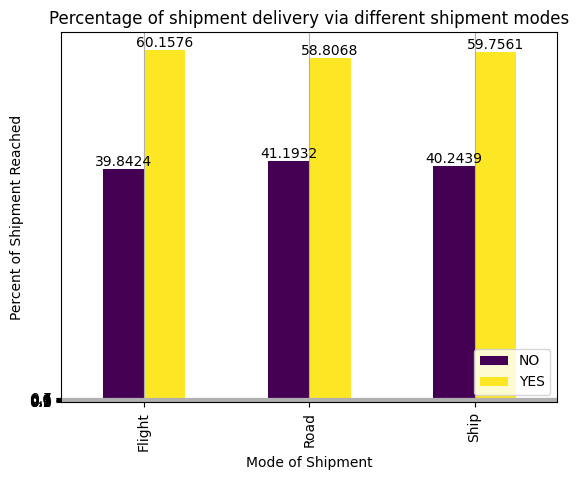

In [24]:
# plot the grouped dataframe as a stacked bar chart
ax = grouped.plot(kind='bar', stacked=False,colormap = "viridis")

# set the x-axis label
ax.set_xlabel('Mode of Shipment')

# set the y-axis label
ax.set_ylabel('Percent of Shipment Reached')

plt.legend(labels = ["No","Yes"])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.yticks([i*0.0001 for i in range(0,8000,1000)])
plt.grid(True)
plt.legend(loc = "lower right",labels = ["NO","YES"])
plt.title("Percentage of shipment delivery via different shipment modes")
# show the plot
plt.show()

## Product importance

In [27]:
grouped = ((df.groupby(["Product_importance","Reached.on.Time_Y.N"])["Reached.on.Time_Y.N"].count()/df.groupby(["Product_importance"])["Reached.on.Time_Y.N"].count()*100)).unstack(fill_value=0)
grouped

Reached.on.Time_Y.N,0,1
Product_importance,,
high,35.021097,64.978903
low,40.721163,59.278837
medium,40.954985,59.045015


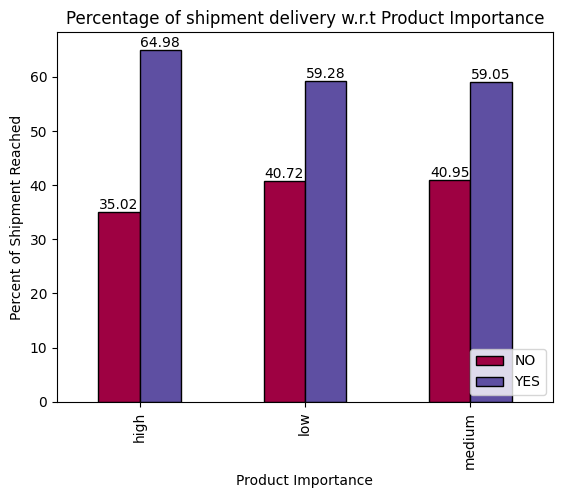

In [28]:
# plot the grouped dataframe as a stacked bar chart
ax = grouped.plot(kind='bar', stacked=False,colormap = "Spectral",edgecolor = "black")

# set the x-axis label
ax.set_xlabel('Product Importance')

# set the y-axis label
ax.set_ylabel('Percent of Shipment Reached')

plt.legend(labels = ["No","Yes"])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')



plt.legend(loc = "lower right",labels = ["NO","YES"])
plt.title("Percentage of shipment delivery w.r.t Product Importance")
# show the plot
plt.show()

## The conversion of shipment received on time or not is affected by customer rating ?

In [30]:
grouped = (df.groupby(["Customer_rating","Reached.on.Time_Y.N"])["Reached.on.Time_Y.N"].count()/df.groupby(["Customer_rating"])["Reached.on.Time_Y.N"].count()*100).unstack(fill_value=0)
grouped

Reached.on.Time_Y.N,0,1
Customer_rating,,
1,41.252796,58.747204
2,41.200924,58.799076
3,39.392586,60.607414
4,40.475103,59.524897
5,39.336711,60.663289


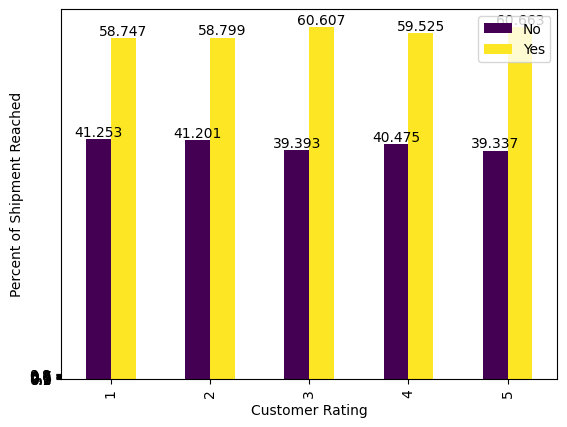

In [31]:
# plot the grouped dataframe as a stacked bar chart
ax = grouped.plot(kind='bar', stacked=False,colormap = "viridis")

# set the x-axis label
ax.set_xlabel('Customer Rating')

# set the y-axis label
ax.set_ylabel('Percent of Shipment Reached')

plt.yticks([i*0.01 for i in range(0,100,10)])

plt.legend(labels = ["No","Yes"])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')


## More detail

In [32]:
cols = df.columns.groupby(df.dtypes)
cols

{int64: ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N'], object: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']}

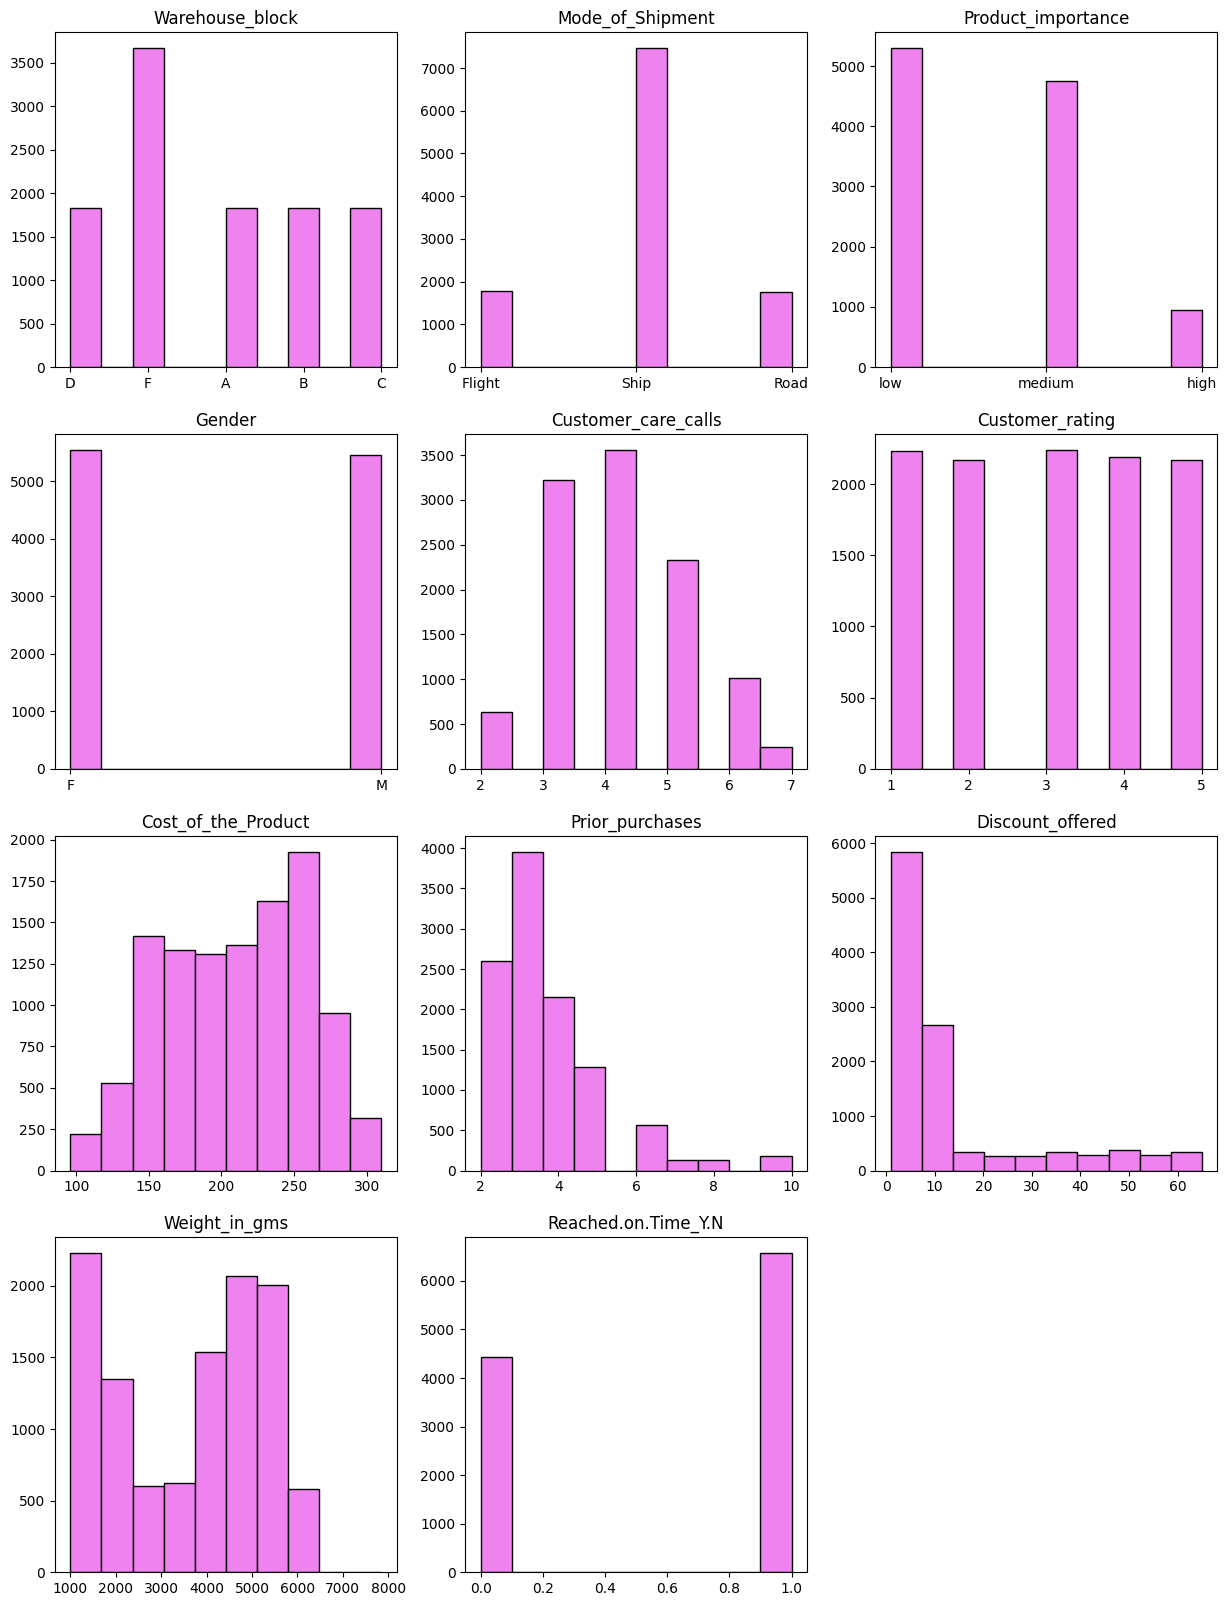

In [34]:
cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']
fig = plt.figure(figsize=(15, 20))

for i in range(len(cols)):
  ax = fig.add_subplot(4, 3, i + 1)
  ax.hist(df[cols[i]],edgecolor = "black",color = "violet")
  ax.set_title(cols[i])